<div style="background-color:#e6f2ff; padding:20px; border-radius:10px;">
<img style="float:left; margin-right:20px;" src='Figures/alinco.png' width="120"/>
<h1 style="color:#000047;">Actividad 3: Similitud Semantica con Word2Vec</h1>
<br style="clear:both"/>
</div>

<div style="border-left:4px solid #000047; padding:10px; margin-top:10px; background:#f5f5f5;">
<b>Objetivo:</b> Aplicar Word2Vec para calcular similitud semantica y encontrar palabras analogas.
</div>

<div style="margin-top:10px;">
<b>Instrucciones generales:</b>
<ul>
<li>Entrena un modelo Word2Vec con el corpus provisto (shakespeare.txt)</li>
<li>Encuentra las 5 palabras mas similares a palabras clave (crooked ----> 5 plbras mas similares)</li>
<li>Calcula similitudes entre grupos de palabras ([imperfections, devout, ascend] ---> [[]])</li>
<li>Visualiza los embeddings con PCA (reducir a 2 dimensiones o a 3)</li>
<li>Construye un sistema de busqueda semantica simple</li>

</ul>
</div>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
import warnings
from gensim.models import Word2Vec, FastText
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
# Calcular similitud coseno entre pares
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

from nltk.tokenize import word_tokenize
import nltk

nltk.download('punkt')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\gabri\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [2]:
import re                                                           # Cargando los datos del archivo de texto
with open('Data/shakespeare.txt') as file:
    texto = file.read().lower()

In [3]:
# Eliminar caracteres y convertir en oraciones
texto = re.sub(r'[^a-zA-Z\s]', ' ', texto)
oraciones = texto.split('\n')

# Tokenizar palabras
sentences = []

for oracion in oraciones:
    tokens = word_tokenize(oracion)
    if len(tokens) > 0:
        sentences.append(tokens)


In [4]:
sentences

[['o', 'for', 'a', 'muse', 'of', 'fire', 'that', 'would', 'ascend'],
 ['the', 'brightest', 'heaven', 'of', 'invention'],
 ['a', 'kingdom', 'for', 'a', 'stage', 'princes', 'to', 'act'],
 ['and', 'monarchs', 'to', 'behold', 'the', 'swelling', 'scene'],
 ['then', 'should', 'the', 'warlike', 'harry', 'like', 'himself'],
 ['assume', 'the', 'port', 'of', 'mars', 'and', 'at', 'his', 'heels'],
 ['leash',
  'd',
  'in',
  'like',
  'hounds',
  'should',
  'famine',
  'sword',
  'and',
  'fire'],
 ['crouch', 'for', 'employment', 'but', 'pardon', 'and', 'gentles', 'all'],
 ['the', 'flat', 'unraised', 'spirits', 'that', 'have', 'dared'],
 ['on', 'this', 'unworthy', 'scaffold', 'to', 'bring', 'forth'],
 ['so', 'great', 'an', 'object', 'can', 'this', 'cockpit', 'hold'],
 ['the', 'vasty', 'fields', 'of', 'france', 'or', 'may', 'we', 'cram'],
 ['within', 'this', 'wooden', 'o', 'the', 'very', 'casques'],
 ['that', 'did', 'affright', 'the', 'air', 'at', 'agincourt'],
 ['o', 'pardon', 'since', 'a', 'croo

In [5]:
print("Número de oraciones:", len(sentences))

Número de oraciones: 6527


In [6]:
# 1. Entrenamiento del modelo Word2Vec con el corpus de shakespeare.txt
modelo_w2v = Word2Vec(sentences, vector_size = 100, window=5, min_count = 2, workers = 4, sg = 1)
print("Vocabulario:", len(modelo_w2v.wv))

Vocabulario: 2843


In [7]:
#2. Encuentro de 5 palabras similares a palabras clave seleccionada
palabras_query = ['celestial', 'severals', 'blood', 'conscience', 'dukedoms']

for palabras in palabras_query:
    if palabras in modelo_w2v.wv:
        similar = modelo_w2v.wv.most_similar(palabras, topn=5)
        print(f'\nPalabra: {palabras}\n')
        for w, s in similar:
            print(f'{w}, {s:.5f}') #Limite número de decimales para ser más visible la similitud


Palabra: celestial

sway, 0.98796
seasons, 0.98751
full, 0.98746
country, 0.98746
blood, 0.98745

Palabra: blood

less, 0.99868
hearts, 0.99862
black, 0.99855
lips, 0.99853
part, 0.99851

Palabra: conscience

end, 0.99828
form, 0.99825
bound, 0.99823
happy, 0.99821
swift, 0.99816

Palabra: dukedoms

favour, 0.99801
heavy, 0.99795
rest, 0.99785
bed, 0.99779
women, 0.99776


In [8]:
#3. Calcular similitudes entre pares de palabras

grupo1_palabras = [
    ('hundred','daughter'),
    ('blood','french'),
    ('plagues','lose'),
    ('children','husband'),
    ('eyes','woman'),
]

print("Similitud entre Pares de Palabras:")
for pal1, pal2 in grupo1_palabras:
    sim = modelo_w2v.wv.similarity(pal1, pal2)
    print(f'Similitud de las Palabras Pares: [{pal1}] con [{pal2}] es: {sim:.5f}')

#Calcular similitudes entre grupo de palabras

grupo2_palabras = ['hundred','daughter','blood','french','plagues','lose','children','husband','eyes','woman']
print("\nSimilitud entre Grupo de Palabras:")
print(f'{grupo2_palabras}\n')

for p_X in grupo2_palabras:
    fila = []

    for p_Y in grupo2_palabras:
        fila.append(round(float(modelo_w2v.wv.similarity(p_X, p_Y)),5))
    print(fila)

Similitud entre Pares de Palabras:
Similitud de las Palabras Pares: [hundred] con [daughter] es: 0.99743
Similitud de las Palabras Pares: [blood] con [french] es: 0.99762
Similitud de las Palabras Pares: [plagues] con [lose] es: 0.99073
Similitud de las Palabras Pares: [children] con [husband] es: 0.99605
Similitud de las Palabras Pares: [eyes] con [woman] es: 0.99525

Similitud entre Grupo de Palabras:
['hundred', 'daughter', 'blood', 'french', 'plagues', 'lose', 'children', 'husband', 'eyes', 'woman']

[1.0, 0.99743, 0.99805, 0.99804, 0.99036, 0.99651, 0.99608, 0.9974, 0.99627, 0.99652]
[0.99743, 1.0, 0.99791, 0.99788, 0.98974, 0.99805, 0.9962, 0.99842, 0.99577, 0.99823]
[0.99805, 0.99791, 1.0, 0.99762, 0.99032, 0.99754, 0.99579, 0.99756, 0.99693, 0.99753]
[0.99804, 0.99788, 0.99762, 1.0, 0.98983, 0.99748, 0.99633, 0.99781, 0.99579, 0.99753]
[0.99036, 0.98974, 0.99032, 0.98983, 1.0, 0.99073, 0.99039, 0.99084, 0.98986, 0.99038]
[0.99651, 0.99805, 0.99754, 0.99748, 0.99073, 1.0, 0.9964

In [9]:
#4. Visualiza los embeddings con PCA (reducir a 2 dimensiones o a 3) representaciones Word2Vec embeddings
#Tome el mismo grupo de palabras
grupo3_palabras = ['hundred','daughter','blood','french','plagues','lose','children','husband','eyes','woman']
#Creo vectores para visualizarlos
vector_gpo = np.array ([modelo_w2v.wv[i] for i in grupo3_palabras if i in modelo_w2v.wv])


In [10]:
vector_gpo

array([[-1.65748000e-01,  2.01370329e-01, -1.32383015e-02,
         1.48254773e-02,  1.54790968e-01, -2.48603478e-01,
         7.63453990e-02,  3.12840462e-01, -1.64545566e-01,
        -1.35821998e-01, -1.11641347e-01, -1.96201742e-01,
        -1.21923752e-01,  1.32273704e-01,  3.97445820e-02,
        -1.87494040e-01,  9.45243314e-02, -1.19133860e-01,
        -1.14612609e-01, -4.20231491e-01,  8.13060924e-02,
         4.32111472e-02,  2.67249346e-01, -1.94845572e-02,
        -6.78828284e-02,  4.47910354e-02, -2.70988226e-01,
        -1.42486796e-01, -2.45075181e-01,  1.81681104e-02,
         2.20772102e-01,  6.83009103e-02,  1.37462690e-01,
        -1.86272010e-01, -6.37273490e-02,  1.26546159e-01,
         3.72278765e-02, -6.89437315e-02, -8.17746073e-02,
        -3.07284385e-01,  1.14907883e-02, -9.78420377e-02,
        -1.53572366e-01, -4.99609895e-02,  1.59519061e-01,
         3.84189337e-02, -5.27644232e-02, -3.50297689e-02,
         6.33158162e-02,  1.62056789e-01,  1.35927469e-0

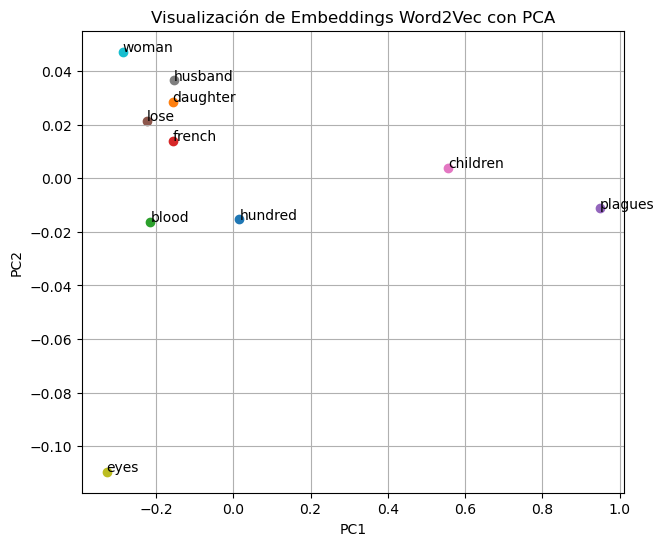

In [11]:
pca = PCA(n_components = 2)
coordenadas = pca.fit_transform(vector_gpo)
plt.figure(figsize=(7,6))

for i, palabra in enumerate(grupo3_palabras):
    if palabra in modelo_w2v.wv:
        plt.scatter(coordenadas[i,0], coordenadas[i,1])
        plt.annotate(palabra, (coordenadas[i,0], coordenadas[i,1]))

plt.title("Visualización de Embeddings Word2Vec con PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.grid(True)
plt.show()

In [12]:
#5. Construye un sistema de búsqueda semántica simple

In [13]:
'''Se utilizo la Class BuscadorSemantico y funciones sentence_embedding_avg y similitud_coseno realizadas en clase'''

# Sentence embedding por promedio de Word2Vec 
def sentence_embedding_avg(oracion, modelo):
    """Promedia los embeddings de las palabras de la oración."""
    tokens = re.findall(r'[a-záéíóúüñ]+', oracion.lower())
    vecs = [modelo.wv[t] for t in tokens if t in modelo.wv]
    if not vecs:
        return np.zeros(modelo.vector_size)
    return np.mean(vecs, axis=0)

def similitud_coseno(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-8)

    
#  Motor de búsqueda semántica con Word2Vec 
class BuscadorSemantico:
    """Búsqueda semántica usando embeddings promediados de Word2Vec."""

    def __init__(self, corpus, modelo):
        self.corpus = corpus
        self.modelo = modelo
        self.embeddings = [sentence_embedding_avg(doc, modelo) for doc in corpus]
        self.embeddings = np.array(self.embeddings )
    
    def buscar(self, query, top_n=3):
        q_emb = sentence_embedding_avg(query, self.modelo)
        if np.linalg.norm(q_emb) == 0:
            return []
        q_emb = q_emb/np.linalg.norm(q_emb)
        norms = np.linalg.norm(self.embeddings, axis=1, keepdims = True)
        norms_emb = self.embeddings/(norms+1e-8)

        sims = norms_emb@q_emb

        indices = sims.argsort()[::-1][:top_n]
        return [(i, sims[i], self.corpus[i]) for i in indices]


In [14]:
query_corpus = [" ".join(sent) for sent in sentences] #genero el corpus de la búsqueda
query_corpus

['o for a muse of fire that would ascend',
 'the brightest heaven of invention',
 'a kingdom for a stage princes to act',
 'and monarchs to behold the swelling scene',
 'then should the warlike harry like himself',
 'assume the port of mars and at his heels',
 'leash d in like hounds should famine sword and fire',
 'crouch for employment but pardon and gentles all',
 'the flat unraised spirits that have dared',
 'on this unworthy scaffold to bring forth',
 'so great an object can this cockpit hold',
 'the vasty fields of france or may we cram',
 'within this wooden o the very casques',
 'that did affright the air at agincourt',
 'o pardon since a crooked figure may',
 'attest in little place a million',
 'and let us ciphers to this great accompt',
 'on your imaginary forces work',
 'suppose within the girdle of these walls',
 'are now confined two mighty monarchies',
 'whose high upreared and abutting fronts',
 'the perilous narrow ocean parts asunder',
 'piece out our imperfections wi

In [15]:
buscador = BuscadorSemantico(query_corpus, modelo_w2v)

In [16]:
query = ["the love is as a paradise",
        "the miracles are infinity",
        "Your Majesty, grant your permission."]

for oracion in query:
    
    resultados = buscador.buscar(oracion, top_n = 5)
    print(f'\nOración: {oracion}')
    for rank, (idx, score, doc) in enumerate(resultados, 1):
        print(f'[{rank}] Similitud = {score:.4f} | {doc}')


Oración: the love is as a paradise
[1] Similitud = 0.9995 | the people love me and the sea is mine
[2] Similitud = 0.9993 | so that as clear as is the summer s sun
[3] Similitud = 0.9993 | idle made of self love which is the most inhibited sin in the
[4] Similitud = 0.9993 | betwixt mine eye and heart a league is took
[5] Similitud = 0.9993 | as twixt a miser and his wealth is found

Oración: the miracles are infinity
[1] Similitud = 0.9989 | the troops are all scattered and the commanders very poor
[2] Similitud = 0.9988 | tibey are the lords and owners of their faces
[3] Similitud = 0.9988 | the mountain or the sea the day or night
[4] Similitud = 0.9987 | are in the field a mighty strength they carry
[5] Similitud = 0.9987 | we are blessed in the change

Oración: Your Majesty, grant your permission.
[1] Similitud = 0.9996 | look back into your mighty ancestors
[2] Similitud = 0.9996 | being your vassal bound to stay your leisure
[3] Similitud = 0.9995 | till your deeds gain them fa